# Time of Flight

Connects `find_xray_shape()` (`shot_characterization/xray.py`) and `find_proton_onset()`
(`shot_characterization/proton.py`): TOF = proton onset time - x-ray onset time.

Onset-to-onset, not peak-to-peak -- the x-ray onset is a tight, validated marker (sub-ns
precision on all 12 shots). The proton onset is less settled: shots 25 and 26 are known
broken (their signal has a positive bump that transitions into a much bigger negative dip,
which confuses the sign-agnostic envelope search) -- excluded below until that's fixed.


In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import shot_log as sl
from helpers import load_channel
from shot_characterization.characterize import characterize
from shot_characterization import VERIFIED_CATEGORY, find_xray_shape, find_proton_onset

BROKEN_PROTON_SHOTS = {25, 26}  # see proton_analysis.ipynb


## Check on one shot

shot 9: xray onset=96.166ns   proton onset=108.666ns   TOF=12.500ns


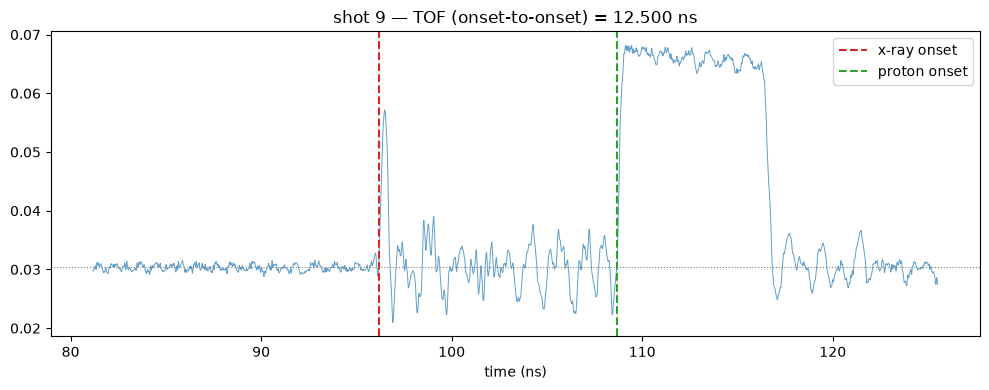

12.499999999999986

In [2]:
def plot_tof(shot, pad_ns=15):
    entry = sl.main_channel_entry(shot)
    kind, path, ch = entry
    t, v, clipped, ydisp = load_channel(sl.DATA_DIR, kind, path, ch)
    res = characterize(t, v, clipped)
    baseline, noise = res["baseline_V"], res["noise_V"]

    xr = find_xray_shape(t, v, baseline, noise)
    if xr is None:
        print(f"shot {shot}: no x-ray found")
        return None
    pr = find_proton_onset(t, v, baseline, xr["peak_i"])
    if pr is None:
        print(f"shot {shot}: no proton found")
        return None

    tof_ns = pr["onset_time_ns"] - xr["onset_time_ns"]
    print(f"shot {shot}: xray onset={xr['onset_time_ns']:.3f}ns   "
          f"proton onset={pr['onset_time_ns']:.3f}ns   TOF={tof_ns:.3f}ns")

    t_ns = t * 1e9
    lo, hi = xr["onset_time_ns"] - pad_ns, pr["peak_time_ns"] + pad_ns
    mask = (t_ns >= lo) & (t_ns <= hi)
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(t_ns[mask], v[mask], lw=0.7, alpha=0.7)
    ax.axvline(xr["onset_time_ns"], color="tab:red", ls="--", label="x-ray onset")
    ax.axvline(pr["onset_time_ns"], color="tab:green", ls="--", label="proton onset")
    ax.axhline(baseline, color="gray", ls=":", lw=0.8)
    ax.legend()
    ax.set_title(f"shot {shot} — TOF (onset-to-onset) = {tof_ns:.3f} ns")
    ax.set_xlabel("time (ns)")
    plt.tight_layout()
    plt.show()
    return tof_ns

plot_tof(9)


## TOF for every verified double-pulse shot (excluding known-broken proton shots)

In [3]:
DOUBLE_PULSE_SHOTS = sorted(s for s, cat in VERIFIED_CATEGORY.items()
                            if cat == "Double pulse (prompt + delayed candidate)")
TOF_SHOTS = [s for s in DOUBLE_PULSE_SHOTS if s not in BROKEN_PROTON_SHOTS]
print(f"{len(DOUBLE_PULSE_SHOTS)} double-pulse shots, {len(TOF_SHOTS)} usable for TOF "
      f"(excluding {sorted(BROKEN_PROTON_SHOTS)})")


12 double-pulse shots, 10 usable for TOF (excluding [25, 26])


## Check on every shot

Same TOF plot as above, for every usable shot -- check these by eye before trusting the summary table below.


shot 9: xray onset=96.166ns   proton onset=108.666ns   TOF=12.500ns


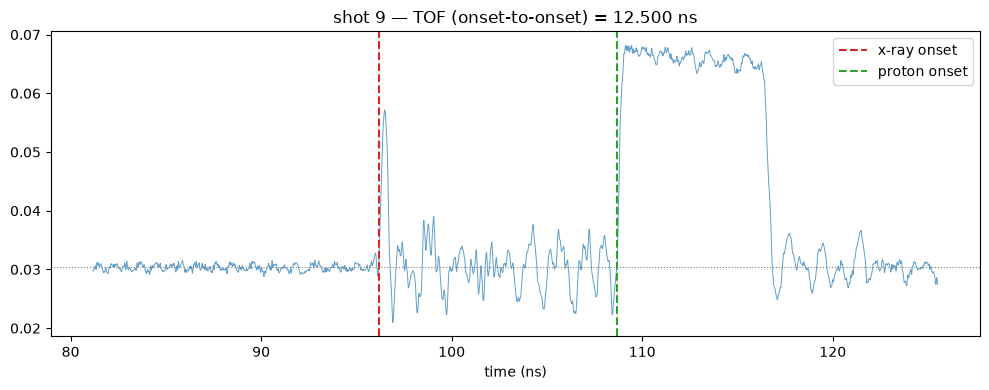

shot 11: xray onset=95.396ns   proton onset=108.646ns   TOF=13.250ns


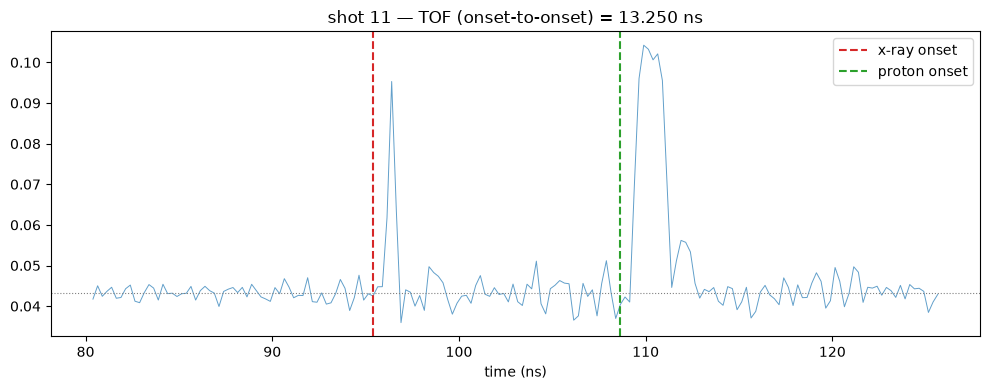

shot 15: xray onset=102.412ns   proton onset=138.123ns   TOF=35.711ns


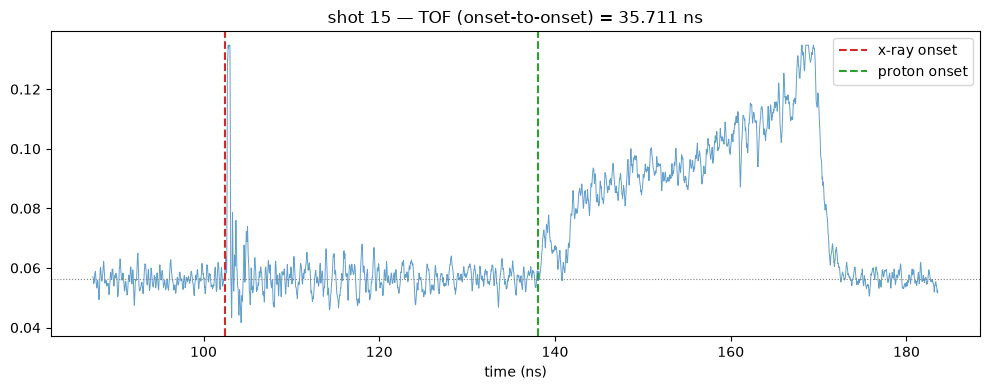

shot 16: xray onset=102.617ns   proton onset=131.531ns   TOF=28.914ns


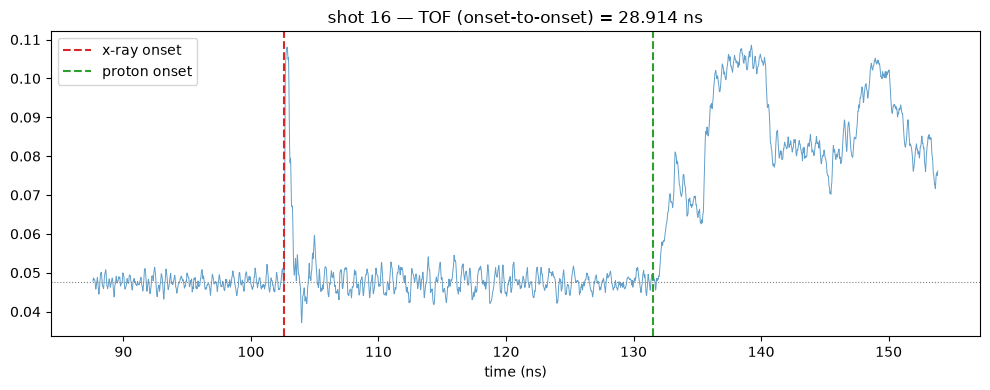

shot 18: xray onset=4.576ns   proton onset=36.217ns   TOF=31.641ns


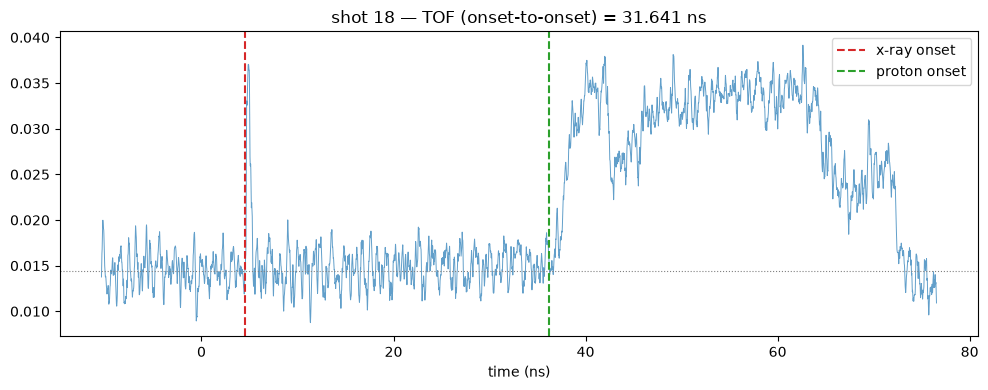

shot 19: xray onset=0.347ns   proton onset=39.042ns   TOF=38.695ns


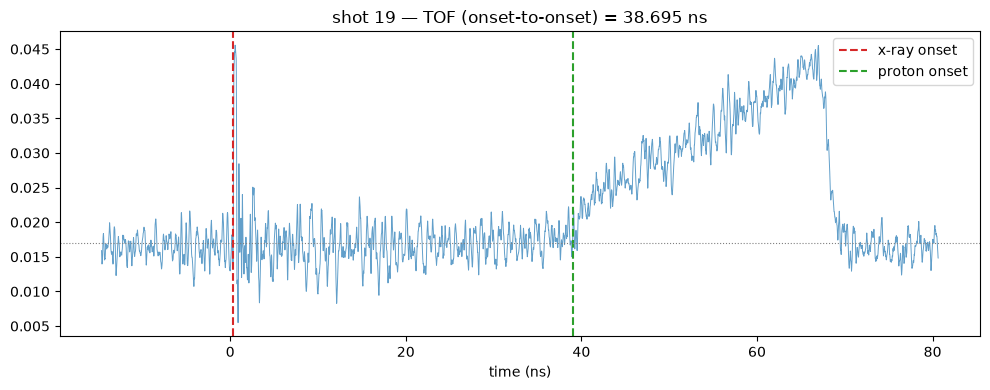

shot 20: xray onset=1.796ns   proton onset=28.601ns   TOF=26.805ns


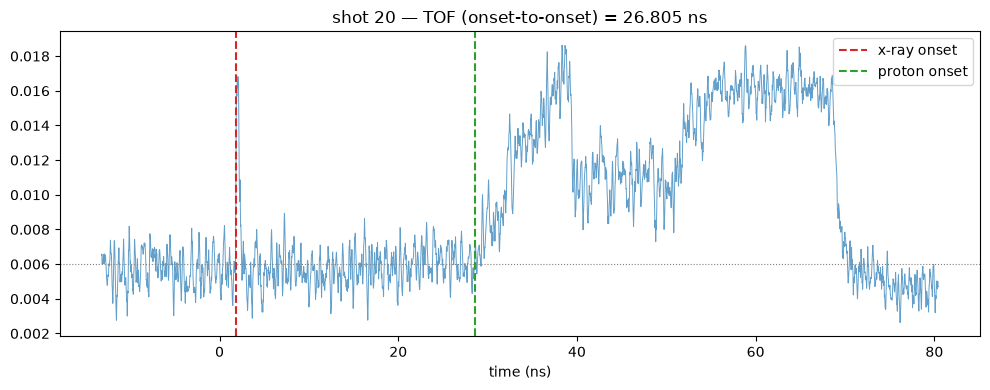

shot 21: xray onset=1.758ns   proton onset=34.516ns   TOF=32.758ns


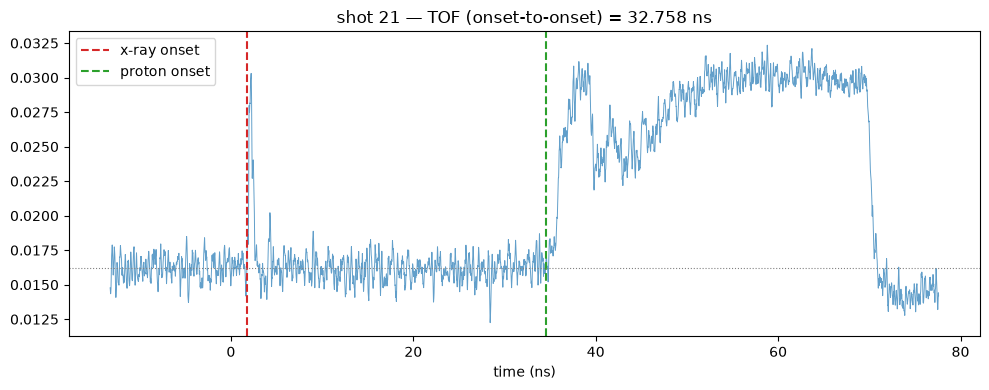

shot 22: xray onset=-1.112ns   proton onset=26.623ns   TOF=27.734ns


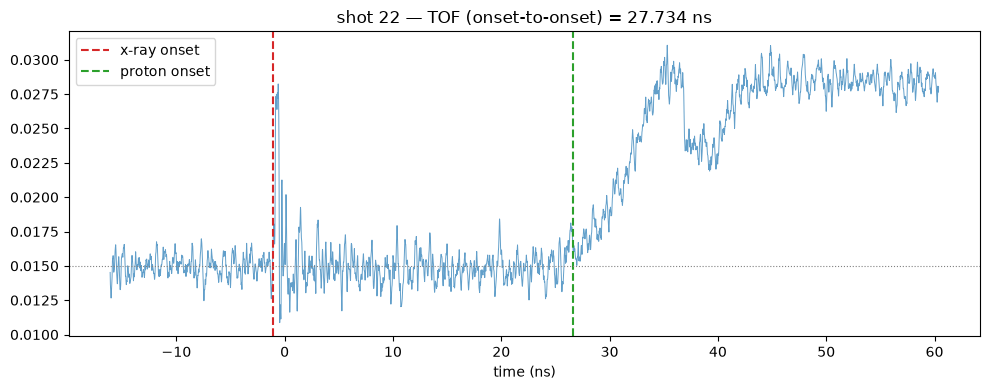

shot 27: xray onset=1.822ns   proton onset=36.095ns   TOF=34.273ns


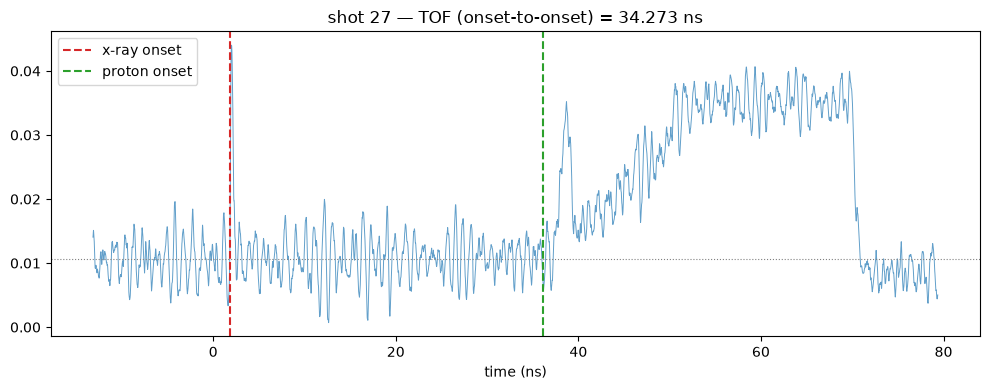

In [4]:
for shot in TOF_SHOTS:
    plot_tof(shot)


## Summary table


In [5]:
rows = []
for shot in TOF_SHOTS:
    entry = sl.main_channel_entry(shot)
    kind, path, ch = entry
    t, v, clipped, ydisp = load_channel(sl.DATA_DIR, kind, path, ch)
    res = characterize(t, v, clipped)
    baseline, noise = res["baseline_V"], res["noise_V"]
    xr = find_xray_shape(t, v, baseline, noise)
    pr = find_proton_onset(t, v, baseline, xr["peak_i"])
    info = sl.SHOT_LOG[shot]
    rows.append(dict(
        shot=shot, target=info["target"], thickness_um=info["thickness_um"],
        xray_onset_ns=round(xr["onset_time_ns"], 3),
        proton_onset_ns=round(pr["onset_time_ns"], 3),
        tof_ns=round(pr["onset_time_ns"] - xr["onset_time_ns"], 3),
    ))

tof_df = pd.DataFrame(rows).set_index("shot")
tof_df


,target,thickness_um,xray_onset_ns,proton_onset_ns,tof_ns
shot,,,,,
9,Cu,25.0,96.166,108.666,12.500
11,Al,25.0,95.396,108.646,13.250
15,Cu film,100.0,102.412,138.123,35.711
16,Mylar,1.0,102.617,131.531,28.914
18,Al,12.5,4.576,36.217,31.641
19,rod,NaN,0.347,39.042,38.695
20,Mylar,1.0,1.796,28.601,26.805
21,Mylar,1.0,1.758,34.516,32.758
22,Mylar,1.0,-1.112,26.623,27.734
